In [1]:
!pip install tensorflow pandas numpy scikit-learn matplotlib openpyxl

In [2]:
from google.colab import files
uploaded = files.upload()

Saving retail_demand_dataset.xlsx to retail_demand_dataset.xlsx


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf

In [4]:
df = pd.read_excel("retail_demand_dataset.xlsx")

print(df.head())
print(df.info())

   day  month  price  discount  marketing_spend  season  demand
0    7     10    937        13             3856       4    8.46
1   20      7    612        31             9207       2  188.47
2   29     10    744        45             7766       3  190.46
3   15      3    332        42             7040       2  257.80
4   11      2    623        15              538       3   61.48
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   day              500 non-null    int64  
 1   month            500 non-null    int64  
 2   price            500 non-null    int64  
 3   discount         500 non-null    int64  
 4   marketing_spend  500 non-null    int64  
 5   season           500 non-null    int64  
 6   demand           500 non-null    float64
dtypes: float64(1), int64(6)
memory usage: 27.5 KB
None


In [5]:
X = df.drop("demand", axis=1)
y = df["demand"]

In [6]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)  # regression output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [10]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 34452.0156 - mae: 163.1987 - val_loss: 37744.2344 - val_mae: 172.9359
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 34099.9297 - mae: 162.2337 - val_loss: 37211.4531 - val_mae: 171.6060
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 33412.9922 - mae: 160.3842 - val_loss: 36086.4648 - val_mae: 168.8033
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 31864.5879 - mae: 156.1665 - val_loss: 33478.5703 - val_mae: 162.2052
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 28367.9355 - mae: 146.6193 - val_loss: 28054.8594 - val_mae: 147.9075
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 21890.8379 - mae: 127.4901 - val_loss: 18963.6367 - val_mae: 121.0936
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12575.6152 - mae: 95.5000 - val_loss: 8285.6768 - val_mae: 79.7369
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4362.4531 - mae: 54.4164 - val_loss: 21

In [11]:
loss, mae = model.evaluate(X_test, y_test)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 228.0250 - mae: 13.1813
Test MAE: 13.181257247924805


In [12]:
predictions = model.predict(X_test)

print("Sample Predictions:")
for i in range(10):
    print("Actual:", y_test.iloc[i], "Predicted:", predictions[i][0])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Sample Predictions:
Actual: 142.71 Predicted: 153.41156
Actual: 301.7 Predicted: 299.32822
Actual: 190.36 Predicted: 194.16852
Actual: 338.34 Predicted: 339.25803
Actual: 148.35 Predicted: 134.18304
Actual: 152.45 Predicted: 161.17464
Actual: 229.47 Predicted: 245.25984
Actual: 74.31 Predicted: 108.40144
Actual: 247.27 Predicted: 266.28906
Actual: 209.09 Predicted: 194.9256


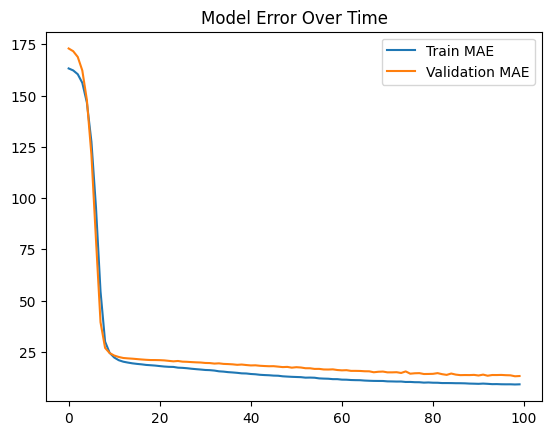

In [13]:
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title("Model Error Over Time")
plt.legend()
plt.show()

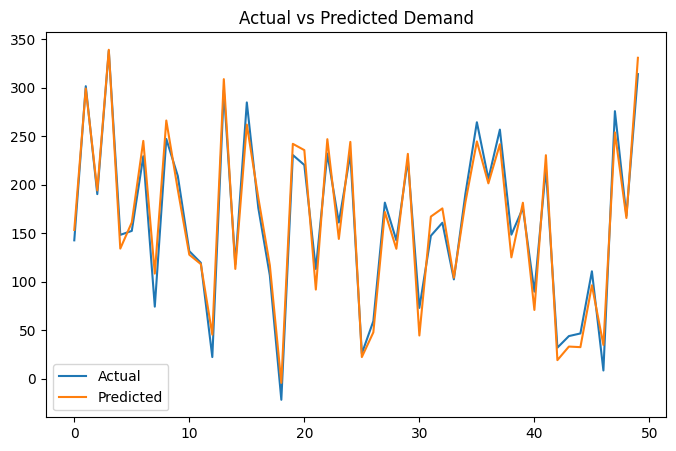

In [14]:
plt.figure(figsize=(8,5))
plt.plot(y_test.values[:50], label="Actual")
plt.plot(predictions[:50], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Demand")
plt.show()

In [15]:
model.save("retail_demand_model.h5")
print("Model Saved Successfully!")

Model Saved Successfully!


In [16]:
sample = np.array([[10, 6, 500, 20, 7000, 3]])
sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)
print("Predicted Demand:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predicted Demand: 187.10394


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
